### Importing necessary modules

In [154]:
import pandas as pd                                                                     # type: ignore
import matplotlib.pyplot as plt                                                         # type: ignore
import seaborn as sns                                                                   # type: ignore
import numpy as np                                                                      # type: ignore
from  sklearn import metrics                                                            # type: ignore
from sklearn.preprocessing import StandardScaler                                        # type: ignore
from sklearn.metrics import roc_auc_score, roc_curve, brier_score_loss                  # type: ignore
from sklearn.metrics import average_precision_score                                     # type: ignore
import tensorflow as tf                                                                 # type: ignore
from sklearn.model_selection import train_test_split                                    # type: ignore
import matplotlib as mpl                                                                # type: ignore
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
mpl.rcParams['figure.figsize'] = (9, 7)
from joblib import dump, load                                                           # type: ignore
import random
import cartopy                                                                          # type: ignore
from matplotlib.offsetbox import AnchoredText                                           # type: ignore
import cartopy.crs as ccrs                                                              # type: ignore
import cartopy.feature as cfeature                                                      # type: ignore

In [155]:
Dakar_lon = -17.467686
Dakar_lat = 14.716677

In [156]:
import sys
sys.path.insert(1, "/home/mendrika/mendrika-phd/codes/nflics")
import nflics  

### Importing dataset

In [157]:
data_part_1 = pd.read_csv("/home/mendrika/mendrika-phd/data/nflics/Nearest-5/full-data-train-part1-5nearest-dakar-with-storm-size.csv", index_col=False)
data_part_2 = pd.read_csv("/home/mendrika/mendrika-phd/data/nflics/Nearest-5/full-data-train-part2-5nearest-dakar-with-storm-size.csv", index_col=False)
data_part_3 = pd.read_csv("/home/mendrika/mendrika-phd/data/nflics/Nearest-5/full-data-train-part3-5nearest-dakar-with-storm-size.csv", index_col=False)
data_part_4 = pd.read_csv("/home/mendrika/mendrika-phd/data/nflics/Nearest-5/full-data-train-part4-5nearest-dakar-with-storm-size.csv", index_col=False)
raw_train_data = pd.concat([data_part_1, data_part_2, data_part_3, data_part_4])

In [158]:
raw_test_data = pd.read_csv("/home/mendrika/mendrika-phd/data/nflics/Nearest-5/full-data-test-5nearest-dakar-with-storm-size.csv", index_col=False)

#### combining dataset and doing some exploratory analysis

In [159]:
# dropping nan values
raw_train_data = raw_train_data.dropna()
raw_test_data = raw_test_data.dropna()

#### Choosing field to include in the data

In [160]:
# Presence or absence of convection in Dakar at time t+1
target_index = "Cb_Dakar"

# Input at time t0
t0 = "year,month,day,hour,minute,"

# latitude and longitude, wavelet power, storm size and distance to Dakar
location = ""
wavelet_power = ""
storm_size = ""
distance = ""
for i in range(1,6):
    location += f"lat{i},lon{i},"
    wavelet_power += f"wp{i},"
    distance += f"ds{i},"
    storm_size += f"size{i},"

# combining all fields to form the feature input
features = t0 + location + wavelet_power + storm_size + distance
field =  features + target_index
field = field.split(',')

### Exploratory data analysis

In [161]:
def log_transform(df, keys):
    df_copy = df.copy()    
    for key in keys:
        transformed = []
        for i in df_copy[key]:
            if i > 0:
                transformed.append(np.log(i))
            else:
                transformed.append(np.log(i+1e-8))    
        df_copy[key] = transformed
    return df_copy

In [162]:
def sqrt_transform(df, keys):
    df_copy = df.copy()    
    for key in keys:
        transformed = []
        for i in df_copy[key]:
            if i >= 0:
                transformed.append(np.sqrt(i)) 
        df_copy[key] = transformed
    return df_copy

In [163]:
to_scale = wavelet_power + storm_size + distance

In [164]:
model = tf.keras.models.load_model("/home/mendrika/mendrika-phd/codes/nflics/model-ML-Dakar/best_model_new_format_Dakar_nearest5_corrected.keras")

Computing the average wavelet power

In [165]:
wp_train = raw_train_data[wavelet_power.split(",")[:-1]].to_numpy().flatten()
wp_array_index = wp_train != 0
mean_wp = np.mean(wp_train[wp_array_index])
median_wp = np.median(wp_train[wp_array_index])
min_wp = np.min(wp_train[wp_array_index])
max_wp = np.max(wp_train[wp_array_index])
std_wp = np.std(wp_train[wp_array_index])

In [166]:
size_train = raw_train_data[storm_size.split(",")[:-1]].to_numpy().flatten()
size_index = size_train != 0
mean_size = np.mean(size_train[size_index])
median_size = np.median(size_train[size_index])
min_size = np.min(size_train[size_index])
max_size = np.max(size_train[size_index])
std_size = np.std(size_train[size_index])

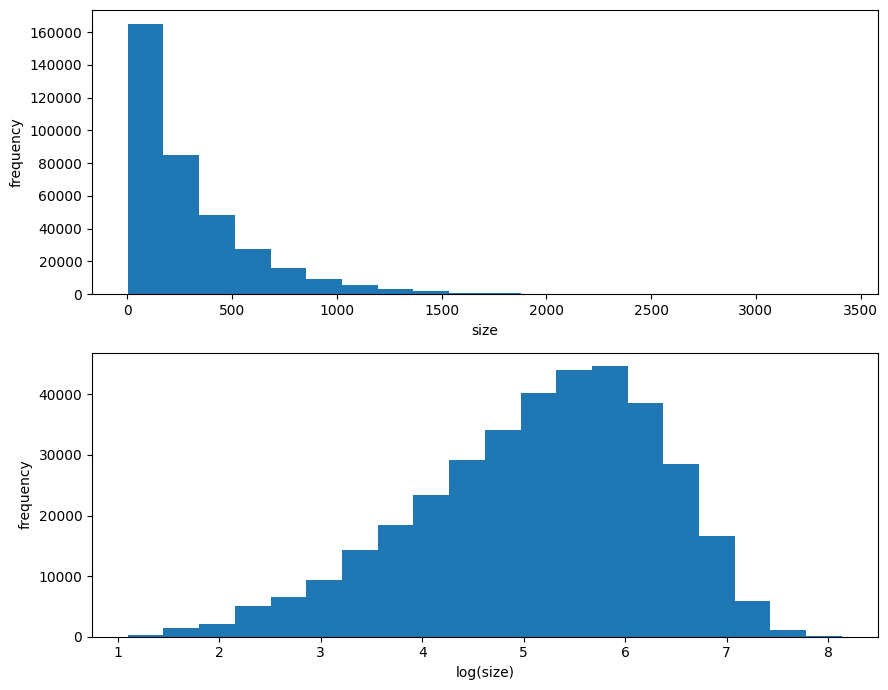

In [167]:
# Create a figure with 2 rows and 1 column
fig, (ax1, ax2) = plt.subplots(2, 1)

# Plot on the first axes
ax1.hist(size_train[size_index]/25, bins=20)
ax1.set_xlabel('size')
ax1.set_ylabel('frequency')

# Plot on the second axes
ax2.hist(np.log(size_train[size_index]/25), bins=20)
ax2.set_xlabel('log(size)')
ax2.set_ylabel('frequency')

plt.tight_layout()  # Adjust spacing between subplots
plt.show()

In [168]:
random.normalvariate(mean_wp, 90)

3436.924620975452

In [169]:
artificial_storms = {
    'year': [], 
    'month': [], 
    'day': [], 
    'hour': [], 
    'minute': [], 
    'lat1': [], 
    'lon1': [], 
    'lat2': [], 
    'lon2': [], 
    'lat3': [], 
    'lon3': [], 
    'lat4': [], 
    'lon4': [], 
    'lat5': [], 
    'lon5': [], 
    'wp1': [], 
    'wp2': [], 
    'wp3': [], 
    'wp4': [], 
    'wp5': [], 
    'size1': [], 
    'size2': [], 
    'size3': [], 
    'size4': [], 
    'size5': [], 
    'ds1': [], 
    'ds2': [], 
    'ds3': [], 
    'ds4': [], 
    'ds5': [], 
}

In [170]:
rng1 = np.random.RandomState(100)
rng2 = np.random.RandomState(2221)

In [171]:
def generate_geo_coords(lat_min, lat_max, lon_min, lon_max):
    artificial_storm_lat = round(rng1.uniform(lat_min, lat_max), 6)
    artificial_storm_lon = round(rng1.uniform(lon_min, lon_max), 6)
    return artificial_storm_lat, artificial_storm_lon

In [172]:
def distance_to_Dakar(lat, lon):
    Dakar_lon = -17.467686
    Dakar_lat = 14.716677
    Dakar_y, Dakar_x = nflics.X0(Dakar_lat, Dakar_lon)
    y, x = nflics.X0(lat, lon)
    return round(np.sqrt((y - Dakar_y)**2 + (x - Dakar_x)**2), 4)

In [173]:
def generate_time():
    yyyy = rng2.randint(2004, 2019)
    mm = rng2.randint(6, 9)
    dd = rng2.randint(1, 31)
    hh = rng2.randint(0, 23)
    m = 0
    return yyyy, mm, dd, hh, m

In [174]:
number_of_data_points = 1000
number_of_storms_to_generate = 2
number_of_storms_in_model = 5

In [175]:
for _ in range(number_of_data_points):
    year, month, day, hour, minute = generate_time()
    #year, month, day, hour, minute = 2024, 9, 1, 17, 0
    artificial_storms["year"].append(year)
    artificial_storms["month"].append(month)
    artificial_storms["day"].append(day)
    artificial_storms["hour"].append(hour)
    artificial_storms["minute"].append(minute)
    for j in range(1, number_of_storms_in_model + 1):        
        if j <= number_of_storms_to_generate:            
            artificial_storm_lat, artificial_storm_lon = generate_geo_coords(10, 18, -18, -10)            
            artificial_storms[f"lat{j}"].append(artificial_storm_lat)
            artificial_storms[f"lon{j}"].append(artificial_storm_lon)
            d_to_Dakar = distance_to_Dakar(artificial_storm_lat, artificial_storm_lon)
            artificial_storms[f"ds{j}"].append(d_to_Dakar)
            #artificial_storms[f"wp{j}"].append(random.normalvariate(mean_wp, 100))
            artificial_storms[f"wp{j}"].append(median_wp)
            #artificial_storms[f"size{j}"].append(random.normalvariate(mean_size, 90))
            artificial_storms[f"size{j}"].append(median_size)
        else:
            artificial_storms[f"lat{j}"].append(14)
            artificial_storms[f"lon{j}"].append(-5)
            artificial_storms[f"ds{j}"].append(430)
            artificial_storms[f"wp{j}"].append(0)
            artificial_storms[f"size{j}"].append(0)


In [176]:
raw_artificial_storm_data = pd.DataFrame.from_dict(artificial_storms, orient='columns')

In [177]:
raw_artificial_storm_data.to_csv(f"/home/mendrika/mendrika-phd/codes/nflics/model-ML-Dakar/output-data/raw-artificial-data-two-storms-same-size-and-wp-different-t0-and-location.csv", index=False)

In [178]:
raw_artificial_storm_data

,year,month,day,hour,minute,lat1,lon1,lat2,lon2,lat3,...,size1,size2,size3,size4,size5,ds1,ds2,ds3,ds4,ds5
0,2004,6,21,6,0,14.347240,-15.773045,13.396141,-11.241791,14,...,5000.0,5000.0,0,0,0,56.2939,212.3982,430,430,430
1,2005,6,26,1,0,10.037751,-17.027447,15.365993,-11.393178,14,...,5000.0,5000.0,0,0,0,165.0121,208.5042,430,430,430
2,2010,8,17,19,0,11.093653,-13.399253,17.130576,-16.326383,14,...,5000.0,5000.0,0,0,0,179.6107,95.2943,430,430,430
3,2013,6,3,8,0,11.482626,-17.132985,11.757580,-10.171010,14,...,5000.0,5000.0,0,0,0,113.0044,263.1539,430,430,430
4,2008,7,19,17,0,16.493465,-16.624472,16.529798,-15.807410,14,...,5000.0,5000.0,0,0,0,70.2353,87.6926,430,430,430
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,2007,6,7,3,0,14.198026,-17.123993,13.212858,-13.569866,14,...,5000.0,5000.0,0,0,0,19.2354,136.4881,430,430,430
996,2011,6,23,4,0,16.951747,-11.290312,15.256734,-17.039608,14,...,5000.0,5000.0,0,0,0,228.4644,24.2074,430,430,430
997,2007,6,14,19,0,17.518346,-11.247634,10.544869,-14.045286,14,...,5000.0,5000.0,0,0,0,238.5162,179.0251,430,430,430
998,2015,8,14,16,0,11.041649,-13.695759,14.596541,-17.373434,14,...,5000.0,5000.0,0,0,0,173.3580,4.4721,430,430,430


In [179]:
artificial_storm_data = log_transform(raw_artificial_storm_data, to_scale.split(',')[:-1])
artificial_storm_data = sqrt_transform(artificial_storm_data, t0.split(',')[:-1])

In [180]:
scaler = load('std_scaler_best_model_new_format_Dakar_nearest5_corrected.bin')

In [181]:
x_new = artificial_storm_data[artificial_storms.keys()]
x_new_std = scaler.transform(x_new)

In [182]:
y_new_pred = model.predict(x_new_std)

30/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


In [183]:
y_art_pred = y_new_pred.flatten()

### Unconditional

In [184]:
pc = pd.read_csv("/home/mendrika/mendrika-phd/codes/nflics/unconditional-probability/dataset-pc-31.csv")

In [185]:
Cb_Dakar_unc = []
for i in range(len(raw_artificial_storm_data)):
    minute = raw_artificial_storm_data["minute"].values[i]    
    hour = raw_artificial_storm_data["hour"].values[i] + 1
    if hour != 24:    
        index_hour = pc["hour"].values == hour
    else:
        index_hour = pc["hour"].values == 0
    index_minute = pc["minute"].values == minute
    index = index_hour * index_minute
    Cb_Dakar_unc.append(pc["probability"].values[index])
Cb_Dakar_unc = np.array(Cb_Dakar_unc).flatten()

In [186]:
index_comp = y_art_pred > Cb_Dakar_unc

In [187]:
df_selected = raw_artificial_storm_data.loc[index_comp]

In [188]:
df_selected

,year,month,day,hour,minute,lat1,lon1,lat2,lon2,lat3,...,size1,size2,size3,size4,size5,ds1,ds2,ds3,ds4,ds5
20,2008,8,3,13,0,14.069591,-17.292319,14.224282,-10.062736,14,...,5000.0,5000.0,0,0,0,22.2036,251.3901,430,430,430
43,2006,7,6,11,0,13.648312,-16.722110,17.693135,-11.299074,14,...,5000.0,5000.0,0,0,0,41.6773,240.1687,430,430,430
99,2006,8,14,21,0,14.792024,-17.996106,14.014509,-13.986191,14,...,5000.0,5000.0,0,0,0,18.2483,117.2774,430,430,430
106,2005,8,10,20,0,14.450480,-16.503082,15.448891,-17.889227,14,...,5000.0,5000.0,0,0,0,32.2800,27.7308,430,430,430
125,2009,6,2,21,0,14.420235,-16.710983,14.548392,-14.114321,14,...,5000.0,5000.0,0,0,0,26.0000,112.0714,430,430,430
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
893,2012,6,4,22,0,14.103161,-17.808542,10.727705,-16.870218,14,...,5000.0,5000.0,0,0,0,25.2389,140.2890,430,430,430
907,2008,7,5,8,0,14.001416,-17.051174,12.358573,-12.680995,14,...,5000.0,5000.0,0,0,0,26.4008,175.7754,430,430,430
938,2007,7,24,9,0,15.500829,-17.915916,15.927838,-13.705045,14,...,5000.0,5000.0,0,0,0,29.9666,136.2975,430,430,430
978,2011,8,28,12,0,15.848584,-16.296669,13.931740,-16.449457,14,...,5000.0,5000.0,0,0,0,58.0000,41.1096,430,430,430


### Checking model weights

In [189]:
W0 = model.get_weights()[0]

In [190]:
W0.shape

(30, 16)

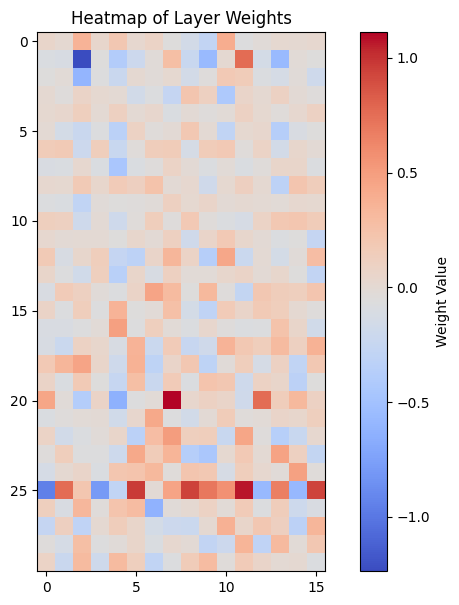

In [191]:
plt.imshow(W0, cmap='coolwarm')  # Adjust cmap for color representation
plt.colorbar(label='Weight Value')
plt.title('Heatmap of Layer Weights')
plt.show()

### Comparing with NFLICS